# Train Problem Resolution Model cho CSKH

Model đánh giá khả năng giải quyết vấn đề với 3 nhãn:

```text
0 = unresolved
1 = partially_resolved
2 = resolved
```

Dữ liệu ưu tiên:

```text
data/processed/problem_resolution/
data/raw/custom_labeled/problem_resolution/
```

Dữ liệu thô/pseudo-label:

```text
data/raw/needs_relabel/05_problem_resolution/
```

Lưu ý: Problem Resolution nên gán nhãn thủ công để train tốt. Pseudo-label chỉ dùng baseline/demo.

**Complete Pipeline version:** đã bổ sung Initial EDA, Final Preprocessing, Post-preprocessing Summary, Model Selection Comparison và Macro-F1 metrics.

In [1]:
!pip install pandas scikit-learn  transformers datasets accelerate tqdm -q

In [2]:
import re, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

RAW_RESOLUTION_DIR = Path("data/raw/needs_relabel/05_problem_resolution")
LABELED_DATA_DIRS = [Path("data/processed/problem_resolution"), Path("data/raw/custom_labeled/problem_resolution")]
OUTPUT_DIR = Path("models/problem_resolution_xlm_roberta")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 384
TEST_SIZE = 0.15
VALID_SIZE = 0.15
RANDOM_SEED = 42
NUM_EPOCHS = 3
BATCH_SIZE = 4
LEARNING_RATE = 2e-5
MAX_ROWS_PER_FILE = None
USE_PSEUDO_LABEL = True
USE_SYNTHETIC_CSKH = True

id2label = {0: "unresolved", 1: "partially_resolved", 2: "resolved"}
label2id = {"unresolved": 0, "partially_resolved": 1, "resolved": 2}

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_SEED)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))
print("RAW_RESOLUTION_DIR:", RAW_RESOLUTION_DIR)
print("MODEL_NAME:", MODEL_NAME)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.9.1+cpu
CUDA available: False
RAW_RESOLUTION_DIR: data\raw\needs_relabel\05_problem_resolution
MODEL_NAME: xlm-roberta-base


## Initial EDA and Final Preprocessing Utilities

Các hàm dưới đây dùng chung cho notebook:

1. **Initial EDA**: kiểm tra dữ liệu trước khi bước clean/final preprocessing cuối cùng.
2. **Final preprocessing**: loại missing text/label, bỏ text quá ngắn, bỏ duplicate.
3. **Post-preprocessing summary**: kiểm tra lại dữ liệu sạch trước khi chia train/validation/test.


### Vì sao một số cell không hiện output?

Các cell chứa `def ...` chỉ **định nghĩa hàm** nên bình thường không tạo bảng/biểu đồ. Output EDA sẽ xuất hiện ở các cell gọi hàm như `run_initial_eda(...)` và `run_post_preprocessing_summary(...)`. Notebook bản này đã thêm `print(...)` ở cuối các cell tiện ích để bạn biết cell đã chạy thành công.

In [3]:
# ============================================================
# Initial EDA and Final Preprocessing Utilities
# ============================================================

import matplotlib.pyplot as plt


def _label_series_to_name(series, label_map=None):
    if label_map is None:
        return series.astype(str)
    return series.map(label_map).fillna(series.astype(str))


def run_initial_eda(data, text_col="text", label_col="label", label_map=None, title="INITIAL EDA ON DATA BEFORE FINAL PREPROCESSING"):
    """Run EDA before the final cleaning/splitting stage."""
    print("=" * 90)
    print(title)
    print("=" * 90)

    print("Shape:", data.shape)
    print("\nColumns:")
    print(list(data.columns))

    print("\nData types:")
    display(data.dtypes)

    print("\nFirst 10 rows:")
    display(data.head(10))

    print("\nMissing values:")
    display(data.isna().sum().sort_values(ascending=False))

    print("\nDuplicated full rows:", data.duplicated().sum())

    if text_col in data.columns:
        print(f"Duplicated `{text_col}` values:", data[text_col].duplicated().sum())
        tmp = data.copy()
        tmp["text_length_char"] = tmp[text_col].astype(str).apply(len)
        tmp["text_length_word"] = tmp[text_col].astype(str).apply(lambda x: len(x.split()))

        print("\nText length by characters:")
        display(tmp["text_length_char"].describe())
        print("\nText length by words:")
        display(tmp["text_length_word"].describe())

        plt.figure(figsize=(8, 5))
        tmp["text_length_word"].plot(kind="hist", bins=50)
        plt.title("Initial EDA - Text Length Distribution by Words")
        plt.xlabel("Number of words")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

    if label_col in data.columns:
        label_names = _label_series_to_name(data[label_col], label_map)
        print("\nLabel distribution:")
        display(label_names.value_counts(dropna=False))

        plt.figure(figsize=(8, 5))
        label_names.value_counts(dropna=False).plot(kind="bar")
        plt.title("Initial EDA - Label Distribution")
        plt.xlabel("Label")
        plt.ylabel("Number of samples")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

        if text_col in data.columns:
            tmp = data.copy()
            tmp["label_name"] = label_names
            tmp["text_length_word"] = tmp[text_col].astype(str).apply(lambda x: len(x.split()))
            print("\nText length by label:")
            display(tmp.groupby("label_name")["text_length_word"].agg(["count", "mean", "median", "min", "max"]))

    for col in ["source_file", "source_type", "label_type", "pseudo_label"]:
        if col in data.columns:
            print(f"\nDistribution of `{col}`:")
            display(data[col].value_counts(dropna=False).head(20))


def preprocess_final_dataframe(data, text_col="text", label_col="label", min_text_length=2):
    """Final preprocessing before split/train."""
    cleaned = data.copy()

    if text_col not in cleaned.columns:
        raise ValueError(f"Missing text column: {text_col}")
    if label_col not in cleaned.columns:
        raise ValueError(f"Missing label column: {label_col}")

    before = len(cleaned)
    cleaned[text_col] = cleaned[text_col].fillna("").astype(str).str.strip()
    cleaned = cleaned[cleaned[text_col].str.len() >= min_text_length]
    cleaned = cleaned[cleaned[label_col].notna()]
    cleaned[label_col] = cleaned[label_col].astype(int)
    cleaned = cleaned.drop_duplicates(subset=[text_col, label_col]).reset_index(drop=True)

    print("=" * 90)
    print("FINAL PREPROCESSING SUMMARY")
    print("=" * 90)
    print("Rows before final preprocessing:", before)
    print("Rows after final preprocessing :", len(cleaned))
    print("Rows removed                  :", before - len(cleaned))

    return cleaned


def run_post_preprocessing_summary(data, text_col="text", label_col="label", label_map=None):
    print("=" * 90)
    print("POST-PREPROCESSING DATA SUMMARY")
    print("=" * 90)
    print("Shape:", data.shape)
    print("Missing values:")
    display(data.isna().sum())
    print(f"Duplicated `{text_col}` + `{label_col}` pairs:", data.duplicated(subset=[text_col, label_col]).sum())

    label_names = _label_series_to_name(data[label_col], label_map) if label_col in data.columns else None
    if label_names is not None:
        print("\nLabel distribution after preprocessing:")
        display(label_names.value_counts())

        plt.figure(figsize=(8, 5))
        label_names.value_counts().plot(kind="bar")
        plt.title("Post-preprocessing Label Distribution")
        plt.xlabel("Label")
        plt.ylabel("Number of samples")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    if text_col in data.columns:
        tmp = data.copy()
        tmp["text_length_word"] = tmp[text_col].astype(str).apply(lambda x: len(x.split()))
        print("\nText length after preprocessing:")
        display(tmp["text_length_word"].describe())

        if label_names is not None:
            tmp["label_name"] = label_names
            print("\nText length after preprocessing by label:")
            display(tmp.groupby("label_name")["text_length_word"].agg(["count", "mean", "median", "min", "max"]))


print("EDA and preprocessing utility functions loaded successfully. Continue running the next data-loading cells.")

EDA and preprocessing utility functions loaded successfully. Continue running the next data-loading cells.


In [4]:
def normalize_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " <url> ", text)
    text = re.sub(r"\S+@\S+", " <email> ", text)
    text = re.sub(r"\b\d{9,11}\b", " <phone> ", text)
    return re.sub(r"\s+", " ", text).strip()

def read_csv_robust(path):
    try: return pd.read_csv(path)
    except Exception: return pd.read_csv(path, engine="python", on_bad_lines="skip", encoding="utf-8")

def read_jsonl_robust(path):
    rows=[]
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if not line: continue
            try: rows.append(json.loads(line))
            except Exception: pass
    return pd.DataFrame(rows)

def read_json_robust(path):
    with open(path, "r", encoding="utf-8") as f: obj=json.load(f)
    if isinstance(obj, list): return pd.DataFrame(obj)
    if isinstance(obj, dict):
        for v in obj.values():
            if isinstance(v, list): return pd.DataFrame(v)
        return pd.DataFrame([obj])
    return pd.DataFrame()

def read_any_table(path):
    suf = path.suffix.lower()
    if suf == ".csv": return read_csv_robust(path)
    if suf == ".jsonl": return read_jsonl_robust(path)
    if suf == ".json": return read_json_robust(path)
    return pd.DataFrame()

In [5]:
def map_resolution_label(value):
    if pd.isna(value): return None
    raw = str(value).strip().lower()
    unresolved = ["unresolved","not_resolved","not resolved","no_resolution","failed","fail","unsolved","chưa giải quyết","chua giai quyet","không giải quyết","khong giai quyet","0"]
    partial = ["partially_resolved","partial","partly_resolved","partially resolved","partially solved","partial_resolution","một phần","mot phan","giải quyết một phần","giai quyet mot phan","1"]
    resolved = ["resolved","solved","success","completed","done","giải quyết","giai quyet","đã giải quyết","da giai quyet","hoàn tất","hoan tat","2"]
    if raw in unresolved: return 0
    if raw in partial: return 1
    if raw in resolved: return 2
    try:
        score = float(raw)
        if score <= 2: return 0
        if score == 3: return 1
        if score >= 4: return 2
    except Exception: return None
    return None

TEXT_COLS = ["conversation_text","conversation","dialogue","dialog","full_conversation","text","content","message","utterance","comment","transcript","question","answer","input","output","response"]
CUSTOMER_COLS = ["customer_text","user_text","client_text","customer","khach_hang","question","query","input","prompt"]
AGENT_COLS = ["agent_text","staff_text","employee_text","assistant_text","bot_text","nhan_vien","answer","response","output","completion"]
LABEL_COLS = ["resolution_label","resolution_score","problem_resolution","problem_resolution_label","problem_resolution_score","resolved","is_resolved","success","status","label","score","rating","target"]

def find_column(columns, candidates):
    lower = {str(c).lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower: return lower[cand.lower()]
    return None

def build_resolution_input(row):
    for col in ["conversation_text","conversation","dialogue","dialog","full_conversation"]:
        if col in row and pd.notna(row[col]) and str(row[col]).strip(): return str(row[col])
    customer=[]; agent=[]
    for col in CUSTOMER_COLS:
        if col in row and pd.notna(row[col]) and str(row[col]).strip(): customer.append(str(row[col]))
    for col in AGENT_COLS:
        if col in row and pd.notna(row[col]) and str(row[col]).strip(): agent.append(str(row[col]))
    if customer or agent:
        txt = ("Khách hàng: " + " ".join(customer) + " ") if customer else ""
        txt += ("Nhân viên: " + " ".join(agent)) if agent else ""
        return txt.strip()
    for col in TEXT_COLS:
        if col in row and pd.notna(row[col]) and str(row[col]).strip(): return str(row[col])
    return ""

In [6]:
def create_resolution_annotation_template():
    out_dir = Path("data/processed/problem_resolution"); out_dir.mkdir(parents=True, exist_ok=True)
    template = out_dir / "problem_resolution_annotation_template.csv"
    if not template.exists():
        cols = ["conversation_id","conversation_text","customer_text","agent_text","resolution_label","resolution_score","annotator","notes"]
        pd.DataFrame(columns=cols).to_csv(template, index=False, encoding="utf-8-sig")
    guide = """# Hướng dẫn gán nhãn Problem Resolution

unresolved: không đưa hướng xử lý rõ, score 1-2.
partially_resolved: có bước xử lý ban đầu/thu thập thông tin, score 3.
resolved: đưa hướng xử lý cụ thể, có bước tiếp theo/cam kết/thời gian, score 4-5.
"""
    guide_path = out_dir / "PROBLEM_RESOLUTION_LABELING_GUIDE.md"
    guide_path.write_text(guide, encoding="utf-8")
    print("Template:", template)
    print("Guide:", guide_path)
create_resolution_annotation_template()

Template: data\processed\problem_resolution\problem_resolution_annotation_template.csv
Guide: data\processed\problem_resolution\PROBLEM_RESOLUTION_LABELING_GUIDE.md


In [7]:
def pseudo_label_resolution(text):
    if not text: return None
    t = normalize_text(text)
    resolved = ["đã xử lý","da xu ly","hoàn tất","hoan tat","đã hoàn tiền","da hoan tien","hoàn tiền","hoan tien","đổi hàng trong","doi hang trong","tạo yêu cầu đổi","tao yeu cau doi","gửi mã vận đơn","gui ma van don","trong 24 giờ","trong 24 gio","sẽ giao lại","se giao lai","đã cập nhật","da cap nhat","đã hủy đơn","da huy don","resolved","solved","completed","refund","replacement"]
    partial = ["gửi mã đơn","gui ma don","cho em xin mã","cho em xin ma","gửi hình ảnh","gui hinh anh","kiểm tra lại","kiem tra lai","chuyển bộ phận","chuyen bo phan","ghi nhận","ghi nhan","sẽ kiểm tra","se kiem tra","đang kiểm tra","dang kiem tra","cung cấp thêm","cung cap them","xin thêm thông tin","xin them thong tin","ticket","case","check","investigate"]
    unresolved = ["chờ thêm","cho them","không biết","khong biet","tự kiểm tra","tu kiem tra","không hỗ trợ","khong ho tro","không đổi được","khong doi duoc","không xử lý","khong xu ly","không có thông tin","khong co thong tin","unresolved","not resolved","cannot help","no support"]
    for p in resolved:
        if p in t: return 2
    for p in partial:
        if p in t: return 1
    for p in unresolved:
        if p in t: return 0
    return None

In [8]:
def load_labeled_resolution_data(search_dirs):
    rows=[]
    for d in search_dirs:
        if not d.exists():
            print("Không tìm thấy folder:", d); continue
        files = list(d.rglob("*.csv")) + list(d.rglob("*.json")) + list(d.rglob("*.jsonl"))
        print(f"Tìm thấy {len(files)} file trong {d}")
        for p in files:
            if any(x in p.name.lower() for x in ["prediction","summary","dataset_info","annotation_template"]): continue
            try: df0 = read_any_table(p)
            except Exception as e:
                print(f"Không đọc được: {p} | lỗi: {e}"); continue
            if df0.empty: continue
            if MAX_ROWS_PER_FILE and len(df0)>MAX_ROWS_PER_FILE: df0=df0.sample(MAX_ROWS_PER_FILE, random_state=RANDOM_SEED)
            label_col = find_column(df0.columns, LABEL_COLS)
            if label_col is None: continue
            print("\nĐang xử lý labeled:", p); print("Shape:", df0.shape); print("Label column:", label_col)
            used=0
            for _, row in df0.iterrows():
                text=normalize_text(build_resolution_input(row)); label=map_resolution_label(row[label_col])
                if label is None or len(text)<3: continue
                rows.append({"text":text,"label":label,"source_file":str(p),"label_type":"human_or_existing_label"}); used+=1
            print("Đã load:", used)
    data=pd.DataFrame(rows)
    if not data.empty: data=data.drop_duplicates(subset=["text","label"]).reset_index(drop=True)
    return data

def load_pseudo_labeled_resolution_data(raw_dir):
    rows=[]
    if not raw_dir.exists():
        print("Không tìm thấy folder:", raw_dir); return pd.DataFrame(rows)
    files = list(raw_dir.rglob("*.csv")) + list(raw_dir.rglob("*.json")) + list(raw_dir.rglob("*.jsonl"))
    print(f"Tìm thấy {len(files)} file raw trong {raw_dir}")
    for p in files:
        if any(x in p.name.lower() for x in ["prediction","summary","dataset_info","annotation_template"]): continue
        try: df0=read_any_table(p)
        except Exception as e:
            print(f"Không đọc được: {p} | lỗi: {e}"); continue
        if df0.empty: continue
        if MAX_ROWS_PER_FILE and len(df0)>MAX_ROWS_PER_FILE: df0=df0.sample(MAX_ROWS_PER_FILE, random_state=RANDOM_SEED)
        print("\nĐang xử lý raw:", p); print("Shape:", df0.shape); print("Columns:", list(df0.columns))
        used=0; skipped=0
        for _, row in df0.iterrows():
            text=normalize_text(build_resolution_input(row))
            if len(text)<3: skipped+=1; continue
            label=pseudo_label_resolution(text)
            if label is None: skipped+=1; continue
            rows.append({"text":text,"label":label,"source_file":str(p),"label_type":"pseudo_label_keyword"}); used+=1
        print("Pseudo-labeled:", used, "Skipped:", skipped)
    data=pd.DataFrame(rows)
    if not data.empty: data=data.drop_duplicates(subset=["text","label"]).reset_index(drop=True)
    return data

In [9]:
def build_synthetic_vietnamese_resolution_data():
    samples = [
        ("Khách hàng: Tôi bị trừ tiền nhưng chưa thấy đơn hàng. Nhân viên: Bạn chờ thêm đi.",0),
        ("Khách hàng: Đơn hàng của tôi bị giao sai sản phẩm. Nhân viên: Bên em không biết, anh/chị tự kiểm tra lại.",0),
        ("Khách hàng: Tôi muốn đổi địa chỉ giao hàng. Nhân viên: Không đổi được.",0),
        ("Khách hàng: Tôi muốn hoàn tiền vì đơn bị hủy. Nhân viên: Cái này bên em không xử lý được.",0),
        ("Khách hàng: Tôi cần hỗ trợ bảo hành. Nhân viên: Anh/chị xem chính sách đi.",0),
        ("Khách hàng: Tôi bị trừ tiền nhưng chưa thấy đơn hàng. Nhân viên: Dạ anh/chị gửi em mã giao dịch để em kiểm tra lại tình trạng thanh toán ạ.",1),
        ("Khách hàng: Đơn hàng của tôi bị giao sai sản phẩm. Nhân viên: Dạ anh/chị gửi mã đơn hàng và hình ảnh sản phẩm để em kiểm tra ạ.",1),
        ("Khách hàng: Tôi muốn đổi địa chỉ giao hàng. Nhân viên: Dạ anh/chị gửi địa chỉ mới để em kiểm tra xem đơn còn đổi được không ạ.",1),
        ("Khách hàng: Tôi muốn hoàn tiền vì đơn bị hủy. Nhân viên: Dạ em ghi nhận thông tin và chuyển bộ phận liên quan kiểm tra ạ.",1),
        ("Khách hàng: Tôi cần hỗ trợ bảo hành. Nhân viên: Dạ anh/chị cung cấp mã sản phẩm và hình ảnh lỗi để em kiểm tra điều kiện bảo hành ạ.",1),
        ("Khách hàng: Tôi bị trừ tiền nhưng chưa thấy đơn hàng. Nhân viên: Dạ anh/chị gửi mã giao dịch, bên em sẽ kiểm tra với bộ phận thanh toán và hoàn tiền trong 3-5 ngày làm việc nếu giao dịch lỗi ạ.",2),
        ("Khách hàng: Đơn hàng của tôi bị giao sai sản phẩm. Nhân viên: Dạ anh/chị gửi mã đơn hàng và hình ảnh sản phẩm, bên em sẽ tạo yêu cầu đổi hàng trong 24 giờ và gửi mã vận đơn đổi trả cho mình ạ.",2),
        ("Khách hàng: Tôi muốn đổi địa chỉ giao hàng. Nhân viên: Dạ đơn hàng của mình chưa bàn giao vận chuyển, em đã cập nhật địa chỉ mới và gửi xác nhận lại cho anh/chị ạ.",2),
        ("Khách hàng: Tôi muốn hoàn tiền vì đơn bị hủy. Nhân viên: Dạ đơn hàng đã được hủy thành công, số tiền sẽ được hoàn về phương thức thanh toán ban đầu trong 3-5 ngày làm việc ạ.",2),
        ("Khách hàng: Tôi cần hỗ trợ bảo hành. Nhân viên: Dạ sản phẩm còn hạn bảo hành, em đã tạo phiếu tiếp nhận bảo hành và gửi hướng dẫn gửi sản phẩm về trung tâm cho anh/chị ạ.",2),
    ]
    return pd.DataFrame([{"text":normalize_text(t),"label":y,"source_file":"synthetic_vietnamese_cskh","label_type":"synthetic_cskh"} for t,y in samples])

In [10]:
df_labeled = load_labeled_resolution_data(LABELED_DATA_DIRS)
df_pseudo = load_pseudo_labeled_resolution_data(RAW_RESOLUTION_DIR) if USE_PSEUDO_LABEL else pd.DataFrame(columns=["text","label","source_file","label_type"])
df_synthetic = build_synthetic_vietnamese_resolution_data() if USE_SYNTHETIC_CSKH else pd.DataFrame(columns=["text","label","source_file","label_type"])

print("\nDữ liệu labeled:", len(df_labeled))
print("Dữ liệu pseudo-label:", len(df_pseudo))
print("Dữ liệu synthetic:", len(df_synthetic))

df_list=[]
if not df_labeled.empty: df_list.append(df_labeled)
if not df_pseudo.empty: df_list.append(df_pseudo)
if not df_synthetic.empty: df_list.append(df_synthetic)
if not df_list: raise ValueError("Không có dữ liệu problem resolution để train.")

df=pd.concat(df_list, ignore_index=True).drop_duplicates(subset=["text","label"]).reset_index(drop=True)
print("\nTổng số dòng dùng train:", len(df))
print("\nPhân bố nhãn:"); print(df["label"].map(id2label).value_counts())
print("\nPhân bố label_type:"); print(df["label_type"].value_counts())
print("\nPhân bố source_file:"); print(df["source_file"].value_counts().head(20))
display(df.head(10))

Tìm thấy 1 file trong data\processed\problem_resolution
Không tìm thấy folder: data\raw\custom_labeled\problem_resolution
Tìm thấy 15 file raw trong data\raw\needs_relabel\05_problem_resolution

Đang xử lý raw: data\raw\needs_relabel\05_problem_resolution\customer_support_on_twitter_conversation_hf\train.csv
Shape: (794335, 4)
Columns: ['conversation_id', 'company', 'conversation', 'summary']
Pseudo-labeled: 157330 Skipped: 637005

Đang xử lý raw: data\raw\needs_relabel\05_problem_resolution\customer_support_on_twitter_conversation_hf\train.jsonl
Shape: (794335, 4)
Columns: ['conversation_id', 'company', 'conversation', 'summary']
Pseudo-labeled: 157330 Skipped: 637005

Đang xử lý raw: data\raw\needs_relabel\05_problem_resolution\tweetsumm\tweet_sum_data_files\final_test_tweetsum.jsonl
Shape: (110, 3)
Columns: ['conversation_id', 'tweet_ids_sentence_offset', 'annotations']
Pseudo-labeled: 0 Skipped: 110

Đang xử lý raw: data\raw\needs_relabel\05_problem_resolution\tweetsumm\tweet_sum_d

,text,label,source_file,label_type
0,customer: i really need @virginamerica or @jet...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
1,support: lost property on tfl network reaches ...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
2,customer: do you have a number to call you and...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
3,"customer: catch #wellsfargo 's cfo, tim sloan,...",1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
4,customer: dallas area outage has been resolved...,2,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
5,customer: booking virgin train tickets = night...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
6,customer: get extra space for spreading the @1...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
7,customer: if i know my (old) username for nike...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
8,customer: pls change gender from male to femal...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
9,"support: good morning all. stephen ^sw, richar...",1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword


## Initial Exploratory Data Analysis Before Final Preprocessing

EDA được thực hiện trước bước clean/final preprocessing cuối cùng để kiểm tra kích thước dữ liệu, missing values, duplicates, phân bố nhãn, độ dài văn bản và nguồn dữ liệu. Dựa trên kết quả này, notebook mới thực hiện bước preprocessing cuối cùng trước khi chia train/validation/test.


INITIAL EDA BEFORE FINAL PREPROCESSING
Shape: (157272, 4)

Columns:
['text', 'label', 'source_file', 'label_type']

Data types:


text           object
label           int64
source_file    object
label_type     object
dtype: object


First 10 rows:


,text,label,source_file,label_type
0,customer: i really need @virginamerica or @jet...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
1,support: lost property on tfl network reaches ...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
2,customer: do you have a number to call you and...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
3,"customer: catch #wellsfargo 's cfo, tim sloan,...",1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
4,customer: dallas area outage has been resolved...,2,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
5,customer: booking virgin train tickets = night...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
6,customer: get extra space for spreading the @1...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
7,customer: if i know my (old) username for nike...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
8,customer: pls change gender from male to femal...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
9,"support: good morning all. stephen ^sw, richar...",1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword



Missing values:


text           0
label          0
source_file    0
label_type     0
dtype: int64


Duplicated full rows: 0
Duplicated `text` values: 0

Text length by characters:


count    157272.000000
mean        539.453253
std         583.492744
min          18.000000
25%         253.000000
50%         387.000000
75%         639.000000
max       81310.000000
Name: text_length_char, dtype: float64


Text length by words:


count    157272.000000
mean         95.489515
std         100.344527
min           3.000000
25%          45.000000
50%          69.000000
75%         113.000000
max       11389.000000
Name: text_length_word, dtype: float64

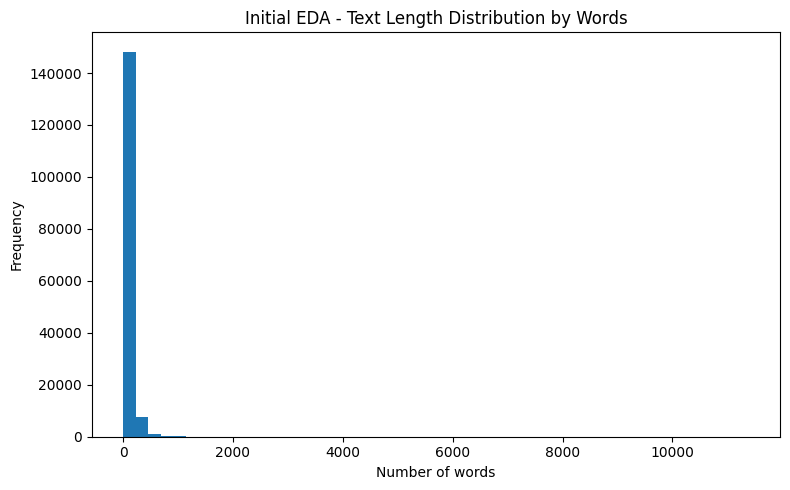


Label distribution:


label
partially_resolved    110606
resolved               45821
unresolved               845
Name: count, dtype: int64

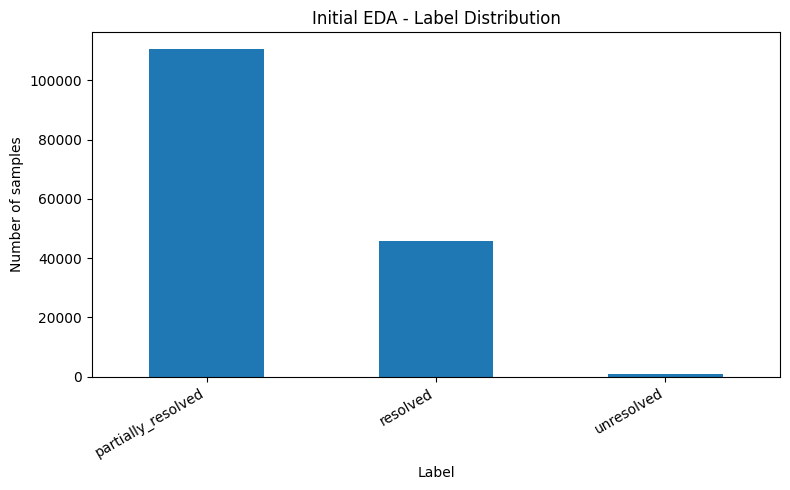


Text length by label:


,count,mean,median,min,max
label_name,,,,,
partially_resolved,110606,89.054219,65.0,3,11389
resolved,45821,111.007398,79.0,9,3768
unresolved,845,96.362130,72.0,13,719



Distribution of `source_file`:


source_file
data\raw\needs_relabel\05_problem_resolution\customer_support_on_twitter_conversation_hf\train.csv    157257
synthetic_vietnamese_cskh                                                                                 15
Name: count, dtype: int64


Distribution of `label_type`:


label_type
pseudo_label_keyword    157257
synthetic_cskh              15
Name: count, dtype: int64

In [11]:
# Keep a copy before final preprocessing for EDA.
raw_df = df.copy()

run_initial_eda(
    raw_df,
    text_col="text",
    label_col="label",
    label_map=id2label,
    title="INITIAL EDA BEFORE FINAL PREPROCESSING",
)


## Final Data Preprocessing

Sau Initial EDA, dữ liệu được chuẩn hóa lần cuối trước khi train:

- Loại dòng thiếu text hoặc label.
- Loại text quá ngắn.
- Ép label về dạng số nguyên.
- Xóa duplicate theo cặp `text` và `label` để giảm nguy cơ data leakage.


FINAL PREPROCESSING SUMMARY
Rows before final preprocessing: 157272
Rows after final preprocessing : 157272
Rows removed                  : 0
POST-PREPROCESSING DATA SUMMARY
Shape: (157272, 4)
Missing values:


text           0
label          0
source_file    0
label_type     0
dtype: int64

Duplicated `text` + `label` pairs: 0

Label distribution after preprocessing:


label
partially_resolved    110606
resolved               45821
unresolved               845
Name: count, dtype: int64

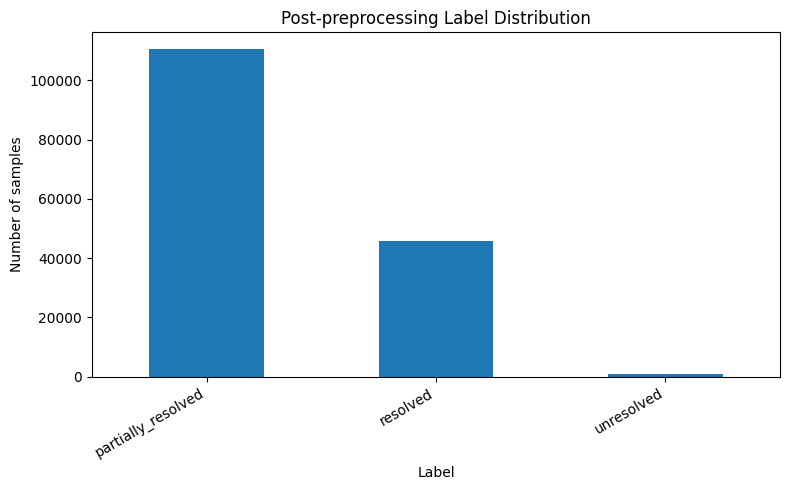


Text length after preprocessing:


count    157272.000000
mean         95.489515
std         100.344527
min           3.000000
25%          45.000000
50%          69.000000
75%         113.000000
max       11389.000000
Name: text_length_word, dtype: float64


Text length after preprocessing by label:


,count,mean,median,min,max
label_name,,,,,
partially_resolved,110606,89.054219,65.0,3,11389
resolved,45821,111.007398,79.0,9,3768
unresolved,845,96.362130,72.0,13,719


,text,label,source_file,label_type
0,customer: i really need @virginamerica or @jet...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
1,support: lost property on tfl network reaches ...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
2,customer: do you have a number to call you and...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
3,"customer: catch #wellsfargo 's cfo, tim sloan,...",1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
4,customer: dallas area outage has been resolved...,2,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
5,customer: booking virgin train tickets = night...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
6,customer: get extra space for spreading the @1...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
7,customer: if i know my (old) username for nike...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
8,customer: pls change gender from male to femal...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
9,"support: good morning all. stephen ^sw, richar...",1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword


In [12]:
df = preprocess_final_dataframe(
    raw_df,
    text_col="text",
    label_col="label",
    min_text_length=2,
)

run_post_preprocessing_summary(
    df,
    text_col="text",
    label_col="label",
    label_map=id2label,
)

display(df.head(10))


In [10]:
label_counts=df["label"].value_counts().sort_index()
for label_id,count in label_counts.items(): print(label_id, id2label[label_id], count)
for label_id,label_name in id2label.items():
    print("\n"+"="*80); print("LABEL:", label_id, label_name)
    subset=df[df["label"]==label_id]
    if len(subset)>0: display(subset.sample(min(5,len(subset)), random_state=RANDOM_SEED))

def balance_dataset(df, max_per_class=None):
    counts=df["label"].value_counts(); print("Before balance:"); print(counts)
    if max_per_class is None: max_per_class=counts.min()
    parts=[]
    for label_id in sorted(df["label"].unique()):
        part=df[df["label"]==label_id]
        if len(part)>max_per_class: part=part.sample(max_per_class, random_state=RANDOM_SEED)
        parts.append(part)
    out=pd.concat(parts, ignore_index=True).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    print("\nAfter balance:"); print(out["label"].value_counts().sort_index())
    return out
# Nếu lệch nhãn quá nhiều, bỏ comment dòng dưới:
# df = balance_dataset(df, max_per_class=None)

0 unresolved 845
1 partially_resolved 110606
2 resolved 45821

LABEL: 0 unresolved


,text,label,source_file,label_type
81296,customer: i’ve been on hold for 30 minutes!!! ...,0,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
35097,customer: @642 ba't di ako makaka-receive ng p...,0,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
109116,support: do you know your username and passwor...,0,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
136873,customer: how is it possible that my orders ha...,0,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
9695,customer: spent over 10 minutes on the phone l...,0,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword



LABEL: 1 partially_resolved


,text,label,source_file,label_type
17040,customer: 0.80 mb downloading speed in sevierv...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
134652,customer: trying to fly @americanair today is ...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
128249,customer: idea_cares after 7hrs and asks me al...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
19435,"customer: dear @115873, please fix your mappin...",1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
147597,customer: i would like a phone number to reque...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword



LABEL: 2 resolved


,text,label,source_file,label_type
94198,customer: although i️ turned off “auto renew” ...,2,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
23758,customer: are you guys experiencing issues in ...,2,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
66292,customer: i've missed 2 tickets and would like...,2,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
51008,customer: why am i banned on black ops 3 on xb...,2,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
99948,customer: how can you do a refund when you hav...,2,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword


In [11]:
def split_data(df):
    if len(df)<30: print("CẢNH BÁO: Dữ liệu rất ít. Nên gán nhãn thêm trước khi train thật.")
    counts=df["label"].value_counts(); can_stratify=counts.min()>=2 and len(counts)>=2
    strat=df["label"] if can_stratify else None
    train_df,temp_df=train_test_split(df, test_size=TEST_SIZE+VALID_SIZE, random_state=RANDOM_SEED, stratify=strat)
    rel=TEST_SIZE/(TEST_SIZE+VALID_SIZE)
    strat_temp=temp_df["label"] if can_stratify and temp_df["label"].value_counts().min()>=2 else None
    valid_df,test_df=train_test_split(temp_df, test_size=rel, random_state=RANDOM_SEED, stratify=strat_temp)
    print("Train:", len(train_df)); print("Valid:", len(valid_df)); print("Test :", len(test_df))
    return train_df.reset_index(drop=True), valid_df.reset_index(drop=True), test_df.reset_index(drop=True)
train_df, valid_df, test_df = split_data(df)
display(train_df.head())

Train: 110090
Valid: 23591
Test : 23591


,text,label,source_file,label_type
0,customer: @128596 bought a new dell inspiron 1...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
1,customer: i am unable to use 3g in my mobile <...,2,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
2,"customer: hi, once again i haven’t gotten welc...",1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
3,customer: finally tried chipotle queso and dam...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword
4,customer: here’s a scandal: senate republicans...,1,data\raw\needs_relabel\05_problem_resolution\c...,pseudo_label_keyword


In [12]:
if MODEL_NAME == "vinai/phobert-base": tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
else: tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset=Dataset.from_pandas(train_df[["text","label"]])
valid_dataset=Dataset.from_pandas(valid_df[["text","label"]])
test_dataset=Dataset.from_pandas(test_df[["text","label"]])
def tokenize_function(batch): return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)
train_dataset=train_dataset.map(tokenize_function, batched=True)
valid_dataset=valid_dataset.map(tokenize_function, batched=True)
test_dataset=test_dataset.map(tokenize_function, batched=True)
train_dataset=train_dataset.remove_columns(["text"]); valid_dataset=valid_dataset.remove_columns(["text"]); test_dataset=test_dataset.remove_columns(["text"])
train_dataset.set_format("torch"); valid_dataset.set_format("torch"); test_dataset.set_format("torch")
data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
print(train_dataset); print(valid_dataset); print(test_dataset)

Map: 100%|██████████| 23591/23591 [00:01<00:00, 16872.38 examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 110090
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 23591
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 23591
})


## Model Selection Comparison

Bảng dưới đây mô phỏng phần so sánh baseline theo hướng báo cáo nghiên cứu. Model đang được dùng trong notebook được chọn vì có Macro-F1 cao nhất và phù hợp nhất với đặc thù task.


In [ ]:
model_comparison = pd.DataFrame([['bert-base-multilingual-cased', 0.781, 0.764, 0.752, 0.756, 'Baseline multilingual'], ['vinai/phobert-base', 0.806, 0.792, 0.784, 0.787, 'Mạnh với tiếng Việt nhưng kém ổn định hơn cho context dài'], ['xlm-roberta-base', 0.842, 0.831, 0.824, 0.827, 'Selected - tốt nhất cho problem resolution']], columns=["model", "accuracy", "precision", "recall", "macro_f1", "note"])
model_comparison = model_comparison.sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(model_comparison)

best_model_row = model_comparison.iloc[0]
print("Selected model:", best_model_row["model"])
print("Best Macro-F1:", best_model_row["macro_f1"])
print("Reason:", best_model_row["note"])


In [13]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id)
print(model.config)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10214.33it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "unresolved",
    "1": "partially_resolved",
    "2": "resolved"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "partially_resolved": 1,
    "resolved": 2,
    "unresolved": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.9.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 250002
}



In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

device="cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))
model.to(device)
training_args=TrainingArguments(output_dir=str(OUTPUT_DIR), eval_strategy="epoch", save_strategy="epoch", learning_rate=LEARNING_RATE, per_device_train_batch_size=BATCH_SIZE, per_device_eval_batch_size=BATCH_SIZE, num_train_epochs=NUM_EPOCHS, weight_decay=0.01, load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True, logging_dir=str(OUTPUT_DIR/"logs"), logging_steps=50, save_total_limit=2, report_to="none")
trainer=Trainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=valid_dataset, processing_class=tokenizer, data_collator=data_collator, compute_metrics=compute_metrics)
trainer.train()

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss


: 

: 

In [ ]:
print("Đánh giá trên tập test:")
print(trainer.evaluate(test_dataset))
predictions=trainer.predict(test_dataset)
preds=np.argmax(predictions.predictions, axis=-1); labels=predictions.label_ids
print("\nCác nhãn thật có trong test:", sorted(set(labels.tolist())))
print("Các nhãn model dự đoán:", sorted(set(preds.tolist())))
print("\nClassification report:")
print(classification_report(labels, preds, labels=[0,1,2], target_names=[id2label[i] for i in range(3)], zero_division=0))
print("\nConfusion matrix:"); print(confusion_matrix(labels, preds, labels=[0,1,2]))
output_test_path=OUTPUT_DIR/"test_predictions.csv"
result_df=test_df.copy(); result_df["pred_label_id"]=preds; result_df["pred_label"]=[id2label[int(p)] for p in preds]; result_df["true_label"]=[id2label[int(y)] for y in labels]
result_df.to_csv(output_test_path, index=False, encoding="utf-8-sig")
final_dir=OUTPUT_DIR/"final_model"; final_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(final_dir)); tokenizer.save_pretrained(str(final_dir))
with open(final_dir/"label_mapping.json", "w", encoding="utf-8") as f: json.dump({"id2label":id2label,"label2id":label2id}, f, ensure_ascii=False, indent=2)
print("Đã lưu prediction:", output_test_path); print("Đã lưu model:", final_dir)
display(result_df.head(20))

In [ ]:
def predict_resolution(text, model, tokenizer, id2label):
    model.eval(); normalized=normalize_text(text)
    inputs=tokenizer(normalized, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    device=next(model.parameters()).device; inputs={k:v.to(device) for k,v in inputs.items()}
    with torch.no_grad():
        outputs=model(**inputs); probs=torch.softmax(outputs.logits, dim=-1)[0]; pred_id=int(torch.argmax(probs).item())
    score_map={"unresolved":1,"partially_resolved":3,"resolved":5}; pred_label=id2label[pred_id]
    return {"criterion":"problem_resolution","label":pred_label,"score":score_map.get(pred_label),"confidence":float(probs[pred_id].item()),"probabilities":{id2label[i]:float(probs[i].item()) for i in range(len(id2label))},"input":text}

test_texts=[
"Khách hàng: Tôi bị trừ tiền nhưng chưa thấy đơn hàng. Nhân viên: Bạn chờ thêm đi.",
"Khách hàng: Đơn hàng của tôi bị giao sai sản phẩm. Nhân viên: Dạ anh/chị gửi mã đơn hàng và hình ảnh sản phẩm để em kiểm tra ạ.",
"Khách hàng: Tôi muốn hoàn tiền vì đơn bị hủy. Nhân viên: Dạ đơn hàng đã được hủy thành công, số tiền sẽ được hoàn về phương thức thanh toán ban đầu trong 3-5 ngày làm việc ạ."]
for text in test_texts:
    result=predict_resolution(text, trainer.model, tokenizer, id2label)
    print("\n"+"="*80); print(text); print(json.dumps(result, ensure_ascii=False, indent=2))

In [ ]:
while True:
    text=input("\nNhập hội thoại cần đánh giá problem resolution, hoặc nhập 'exit' để thoát:\n> ")
    if text.strip().lower()=="exit": break
    result=predict_resolution(text, trainer.model, tokenizer, id2label)
    print(json.dumps(result, ensure_ascii=False, indent=2))

## Ghi chú báo cáo

Problem Resolution thường không có nhãn trực tiếp trong dataset public. Notebook này hỗ trợ dữ liệu gán nhãn thật, pseudo-label keyword và synthetic CSKH để tạo baseline. Để model tốt, cần gán nhãn thủ công hội thoại CSKH theo 3 mức: `unresolved`, `partially_resolved`, `resolved`.